In [27]:
import cupy as cp
import math
import matplotlib.pyplot as plt
from model.network import Network

## Loading the Data

In [28]:
training_path = "input/training.txt"
validation_path = "input/validation.txt"

with open(training_path, "r", encoding="utf-8") as file:
    training_data = file.read()

with open(validation_path, "r", encoding="utf-8") as file:
    validation_data = file.read()

training_data = list(training_data)
validation_data = list(validation_data)

x_train = training_data[:-1]
y_train = training_data[1:]

x_test = validation_data[:-1]
y_test = validation_data[1:]

print(f"Training data length: X={len(x_train)}, Y={len(y_train)}")
print(f"Validation data length: X={len(x_test)}, Y={len(y_test)}")

Training data length: X=880791, Y=880791
Validation data length: X=234596, Y=234596


In [29]:
vocabulary = sorted(set(training_data).union(set(validation_data)))
print(f"Vocabulary size: {len(vocabulary)}")

Vocabulary size: 65


In [30]:
def char_to_index(char: str) -> int:
    return vocabulary.index(char)

def index_to_char(index: int) -> str:
    return vocabulary[index]

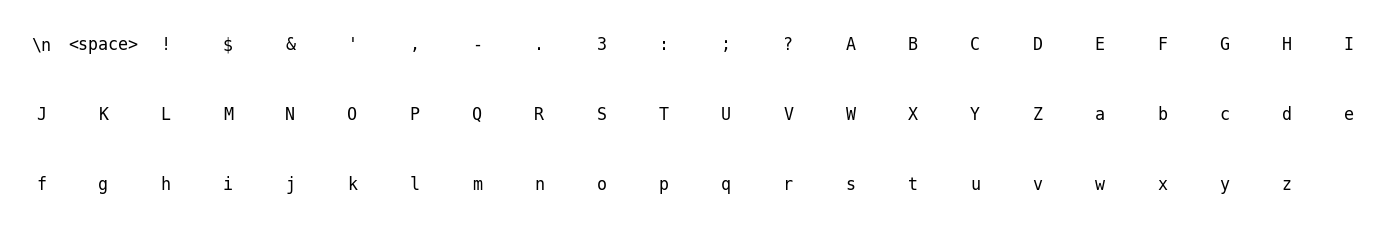

In [31]:
cols = 22
rows = math.ceil(len(vocabulary) / cols)

fig, ax = plt.subplots(figsize=(14, max(2, rows * 0.8)))

for index, token in enumerate(vocabulary):
    row, col = divmod(index, cols)
    display_token = {" ": "<space>", "\n": "\\n", "\t": "\\t"}.get(token, token)
    y = rows - row - 1
    ax.text(col, y, display_token, ha="center", va="center", fontsize=12, family="monospace")

ax.set_xlim(-0.5, cols - 0.5)
ax.set_ylim(-0.5, rows - 0.5)
ax.set_xticks(range(cols))
ax.set_yticks(range(rows))
ax.grid(True, linestyle=":", alpha=0.3)
plt.axis("off")
plt.tight_layout()
plt.show()

In [32]:
x_train_indices = cp.asarray([char_to_index(char) for char in x_train], dtype=cp.int32)
y_train_indices = cp.asarray([char_to_index(char) for char in y_train], dtype=cp.int32)
x_test_indices = cp.asarray([char_to_index(char) for char in x_test], dtype=cp.int32)
y_test_indices = cp.asarray([char_to_index(char) for char in y_test], dtype=cp.int32)

## Building the Model

In [33]:
embedding_dim = 64
hidden_size = 256
hidden_2_size = 128

layer_definitions = [
    {"type": "Embedding", "num_embeddings": len(vocabulary), "embedding_dim": embedding_dim},
    {"type": "LSTM", "input_size": embedding_dim, "num_neurons": hidden_size},
    {"type": "LSTM", "input_size": hidden_size, "num_neurons": hidden_2_size},
    {"type": "Softmax", "input_size": hidden_2_size, "num_neurons": len(vocabulary)},
]

network = Network(layer_definitions=layer_definitions)
network.describe()

Network Architecture

Layer 1: EmbeddingLayer
  Embeddings Shape: (65, 64)
  Parameters: 4,160

Layer 2: LSTMLayer
  Weights Shape: (64, 256) | Recurrent Weights Shape: (256, 256) | Gates: 4
  Parameters: 328,704

Layer 3: LSTMLayer
  Weights Shape: (256, 128) | Recurrent Weights Shape: (128, 128) | Gates: 4
  Parameters: 197,120

Layer 4: SoftmaxLayer
  Weights Shape: (128, 65) | Biases Shape: (65,)
  Parameters: 8,385

Total Parameters: 538,369


## Training the Model

In [34]:
def one_hot(indices: cp.ndarray, num_classes: int) -> cp.ndarray:
    encoded = cp.zeros((indices.shape[0], num_classes), dtype=cp.float32)
    encoded[cp.arange(indices.shape[0]), indices] = 1.0
    return encoded

In [35]:
def reshape_streams(
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    max_columns: int | None = None,
 ) -> tuple[cp.ndarray, cp.ndarray]:
    usable_tokens = (x_indices.shape[0] // batch_size) * batch_size
    x = x_indices[:usable_tokens].reshape(batch_size, -1)
    y = y_indices[:usable_tokens].reshape(batch_size, -1)

    if max_columns is not None:
        x = x[:, :max_columns]
        y = y[:, :max_columns]

    return x, y

In [36]:
def evaluate(
    network: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    max_steps: int | None = None,
) -> float:
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )

    network.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for step in range(total_steps):
        y_prob = network.forward(x[:, step])[-1]
        y_true = one_hot(y[:, step], len(vocabulary))
        total_loss += float(network.cce_loss(y_prob, y_true).item())

        if (step + 1) % sequence_length == 0:
            network.reset_states(batch_size=batch_size, dtype=cp.float32)

    return math.exp(total_loss / total_steps)


In [37]:
def train_epoch(
    network: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    learning_rate: float,
    max_steps: int | None = None,
    weight_decay_lambda: float = 0.0,
    momentum: float = 0.0,
) -> float:
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )
    network.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for chunk_start in range(0, total_steps, sequence_length):
        chunk_end = min(chunk_start + sequence_length, total_steps)
        output_errors = []

        for step in range(chunk_start, chunk_end):
            y_prob = network.forward(x[:, step])[-1]
            y_true = one_hot(y[:, step], len(vocabulary))
            total_loss += float(network.cce_loss(y_prob, y_true).item())
            output_errors.append(y_prob - y_true)

        network.backward_sequence(output_errors, batch_size)
        network.update_parameters(learning_rate, weight_decay_lambda, momentum)
        network.reset_states(batch_size=batch_size, dtype=cp.float32)

    return math.exp(total_loss / total_steps)


In [38]:
sequence_length = 128
batch_size = 64
epochs = 500
train_steps_per_epoch = 3072
validation_steps = 1024
base_learning_rate = 0.05
min_learning_rate = 0.0005
weight_decay_lambda = 1e-4
momentum = 0.9
early_stopping_patience = 25


In [39]:
epoch_summaries = []

total_steps = epochs * train_steps_per_epoch
global_step = 0

best_model = None
best_perplexity = float("inf")
epochs_without_improvement = 0

for epoch in range(1, epochs + 1):
    learning_rate = min_learning_rate + 0.5 * (base_learning_rate - min_learning_rate) * (1 + math.cos(math.pi * global_step / total_steps))

    train_perplexity = train_epoch(
        network=network,
        x_indices=x_train_indices,
        y_indices=y_train_indices,
        batch_size=batch_size,
        sequence_length=sequence_length,
        learning_rate=learning_rate,
        max_steps=train_steps_per_epoch,
        weight_decay_lambda=weight_decay_lambda,
        momentum=momentum,
    )
    test_perplexity = evaluate(
        network=network,
        x_indices=x_test_indices,
        y_indices=y_test_indices,
        batch_size=batch_size,
        sequence_length=sequence_length,
        max_steps=validation_steps,
    )

    epoch_summary = {
        "epoch": epoch,
        "learning_rate": learning_rate,
        "train_perplexity": train_perplexity,
        "test_perplexity": test_perplexity,
    }
    epoch_summaries.append(epoch_summary)

    if epoch % 50 == 0 or epoch == 1:
        print(epoch_summary)

    if test_perplexity < best_perplexity:
        best_perplexity = test_perplexity
        best_model = network.clone()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    global_step += train_steps_per_epoch

    if epochs_without_improvement >= early_stopping_patience:
        print(f"Early stopping triggered after {epoch} epochs due to no improvement.")
        break


{'epoch': 1, 'learning_rate': 0.05, 'train_perplexity': 36.52635683053824, 'test_perplexity': 25.432371908488125}
{'epoch': 50, 'learning_rate': 0.048836238702551174, 'train_perplexity': 5.356841679327902, 'test_perplexity': 5.660712197015048}
{'epoch': 100, 'learning_rate': 0.045364180569719074, 'train_perplexity': 4.400144638108646, 'test_perplexity': 5.026945681834542}
{'epoch': 150, 'learning_rate': 0.03992320629898622, 'train_perplexity': 3.9620330482212545, 'test_perplexity': 4.902824043008161}
Early stopping triggered after 178 epochs due to no improvement.


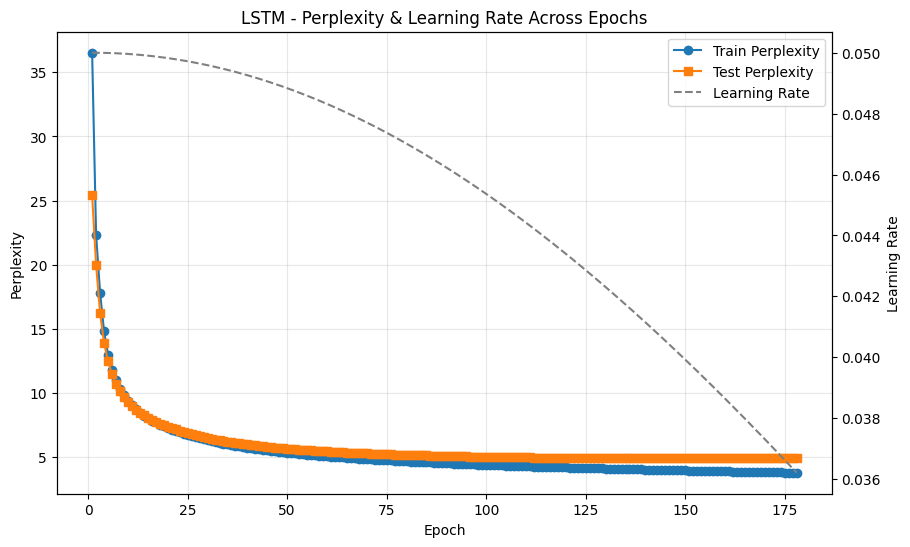

In [40]:
epochs_plot = [summary["epoch"] for summary in epoch_summaries]
train_perplexities = [summary["train_perplexity"] for summary in epoch_summaries]
test_perplexities = [summary["test_perplexity"] for summary in epoch_summaries]
learning_rates = [summary["learning_rate"] for summary in epoch_summaries]

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(epochs_plot, train_perplexities, marker="o", label="Train Perplexity")
ax1.plot(epochs_plot, test_perplexities, marker="s", label="Test Perplexity")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Perplexity")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs_plot, learning_rates, color="gray", linestyle="--", linewidth=1.5, label="Learning Rate")
ax2.set_ylabel("Learning Rate")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.title("LSTM - Perplexity & Learning Rate Across Epochs")
plt.show()

In [41]:
def generate_text(
    network: Network,
    seed_text: str,
    length: int = 250,
    temperature: float = 0.8,
    print_during: bool = True,
) -> str:
    network.reset_states(batch_size=1, dtype=cp.float32)
    generated = list(seed_text)

    if print_during:
        print(seed_text, end="")

    for character in seed_text:
        token_index = cp.asarray([char_to_index(character)], dtype=cp.int32)
        network.forward(token_index)

    current_character = seed_text[-1]

    for _ in range(length):
        token_index = cp.asarray([char_to_index(current_character)], dtype=cp.int32)
        y_prob = network.forward(token_index)[-1][0]
        log_prob = cp.log(y_prob + 1e-9) / temperature
        scaled_prob = cp.exp(log_prob - cp.max(log_prob))
        scaled_prob = scaled_prob / cp.sum(scaled_prob)
        next_index = int(
            cp.random.choice(len(vocabulary), size=1, p=scaled_prob)[0].item()
        )
        current_character = index_to_char(next_index)
        generated.append(current_character)

        if print_during:
            print(current_character, end="", flush=True)

    return "".join(generated)

In [42]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.9, print_during=True)

DANIEL:
Doked yet thought me, one, yet
Ameebor'd of Romeace are forsoother
To love me pleamen access on the couchious hight
inoot of the parely looks like your fawn.

Groom:
What, he would crieade them hose with king,
And marer of my men, begins, my lord;
Pome is the clack his shaply Duke word. I thank you the birth
When my maketh me wold has free of uponly end
Make a little foot to this as my heady?

Bothers:
An by might here to the truity
Joken and so matter'd chicked may thingly
A city, when thou hast thou did feljoss comm'dded,
Your at to see us? Couchness, as down the truth, or faithly and sua too
Clain our wompently of the heart
I go, but this him a most inlown:
The varry Milloable friends him again
Mays here,' where thy serving of mest,
Scondow'dly for it, nouth of Norgected mountry thee the death,
I would that kindly the rifeldy with him: my loved.

KING RICHARD III:

DUKE ONONES:

KING EdWar:
I am all the counsel of him Forth friare.

ANTIY:
Let me lute young prought you had t

In [43]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.7, print_during=True)

DANIEL:
As prove a man of live I near him thy head,
Sheep may left my set haw not them for his and of
the growned how that dost my provus for this for your highness
In wail it with the world, and beauties,
He shall be sweet repent thee house and fly him to the field.
I may be gone, thousand the high and death,
And to a holy 'twas this death, and allied them
Makes your such of thee be but with muster father that we love
Which with my brother your company.

CORIOLANUS:
Then thou art my souls, go ender than your love,
And when it instrock but, all the sennow
Aday it your heart, I warrant it. A bound,
And thence furthest heart him your man hither bewels.
All the words of the earth for the very see I did the business
We should but a brought to the morant,
Thou to the matter, my lord, and thy bloody the earth,
And thou art not seple that hath you that ends.

CRATINGUS:
I am hell:
'Tis my hole greets his was of it all indeed.

LUCIO:
How hewell, my mistry dight, beet sin,
Sincasting, I prove 

In [44]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.5, print_during=True)

DANIELA:
This is not the bosom the bosom thee to see the rest down him;
I would was the poor thou wilt means the bear
The fair and and seen the stands that noble down.

ESCALUS:
I would a good that I have been them hother,
The bown the cried to such believe it out.

ANGELO:
What hold the many a friends him and still
As which he shall we the common nor faith.

KING RICHARD III:
Well, find the land and say the fearful to the brought
That the worst the world before you have been a ground.

DUKE VINCENTIO:
It is the partion's the Clifford of the with off
the think to the book of it worse the sent of your and life would
That when to the send the hath a death,
Which you will be a bold broved and not the season
And that had his partionany complandent
To come a kingly this valiant a country,
That you come and the love a farlion, like peason
And the princes with my son, and yet the peessing them.
I will the gods to a good, and the have been a partion,
I am the borne to the exchange the common t

In [45]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.3, print_during=True)

DANIEL:
I will you the bear it with the earth,
The sends the sends a sounds that when you that you are
The service the world and so the love,
And the send a stranger the brother than the season,
And the should have lived that I am a pity.

PRINCE EDWARD:
Then that with him of the world and many of the prifortune.

DUKE VINCENTIO:
I thank the hath the brother the truth of the season.

CORIOLANUS:
Then thou hast the commanded the bear thee,
And the send the say who heart the command the seen
And so prove a putity some than the rogues.

GLOUCESTER:
What was the common the changed of the season,
I may not to my heart with a truth upon the house,
To see the heart to the death, and the season,
That I have not the prove a state and seen
The stand the cause my looks better to the bear
As my son in the princes of the bold,
That I have heart and have not the more than the country.

CAMILLO:
It were the more man I will be a brown to my heart
That upon the earth and like the world
That she will be